Loaded fold 0 train partition : (12537, 81)
  risky_upgrade : 1,094  (8.7%)
  safe_upgrade  : 11,443  (91.3%)
  Baseline default rate : 8.73%
Final variables for ARM (fold 0) : 22
  [Note: original paper used 16 variables; this fold uses 22 after VIF threshold=5 — see NB03/NB03b fold-specific output.]

Parameters:
  min_support (risky)     : 0.2
  min_support (safe)      : 0.05
  min_confidence          : 0.6
  lift_vs_baseline        : 2.0x
  min_conf_diff           : 0.1
  max_antecedent_len      : 3
  agreement_threshold     : 0.75  [grouping]

[Step 1] Discretising variables into bins (fold 0)...
  Attr52                              distress=HIGH
  Attr49                              distress=LOW
  Attr38                              distress=LOW
  working_capital_to_assets           distress=LOW
  Attr30                              distress=HIGH
  Attr25                              distress=LOW
  Attr13                              distress=LOW
  Attr24                         

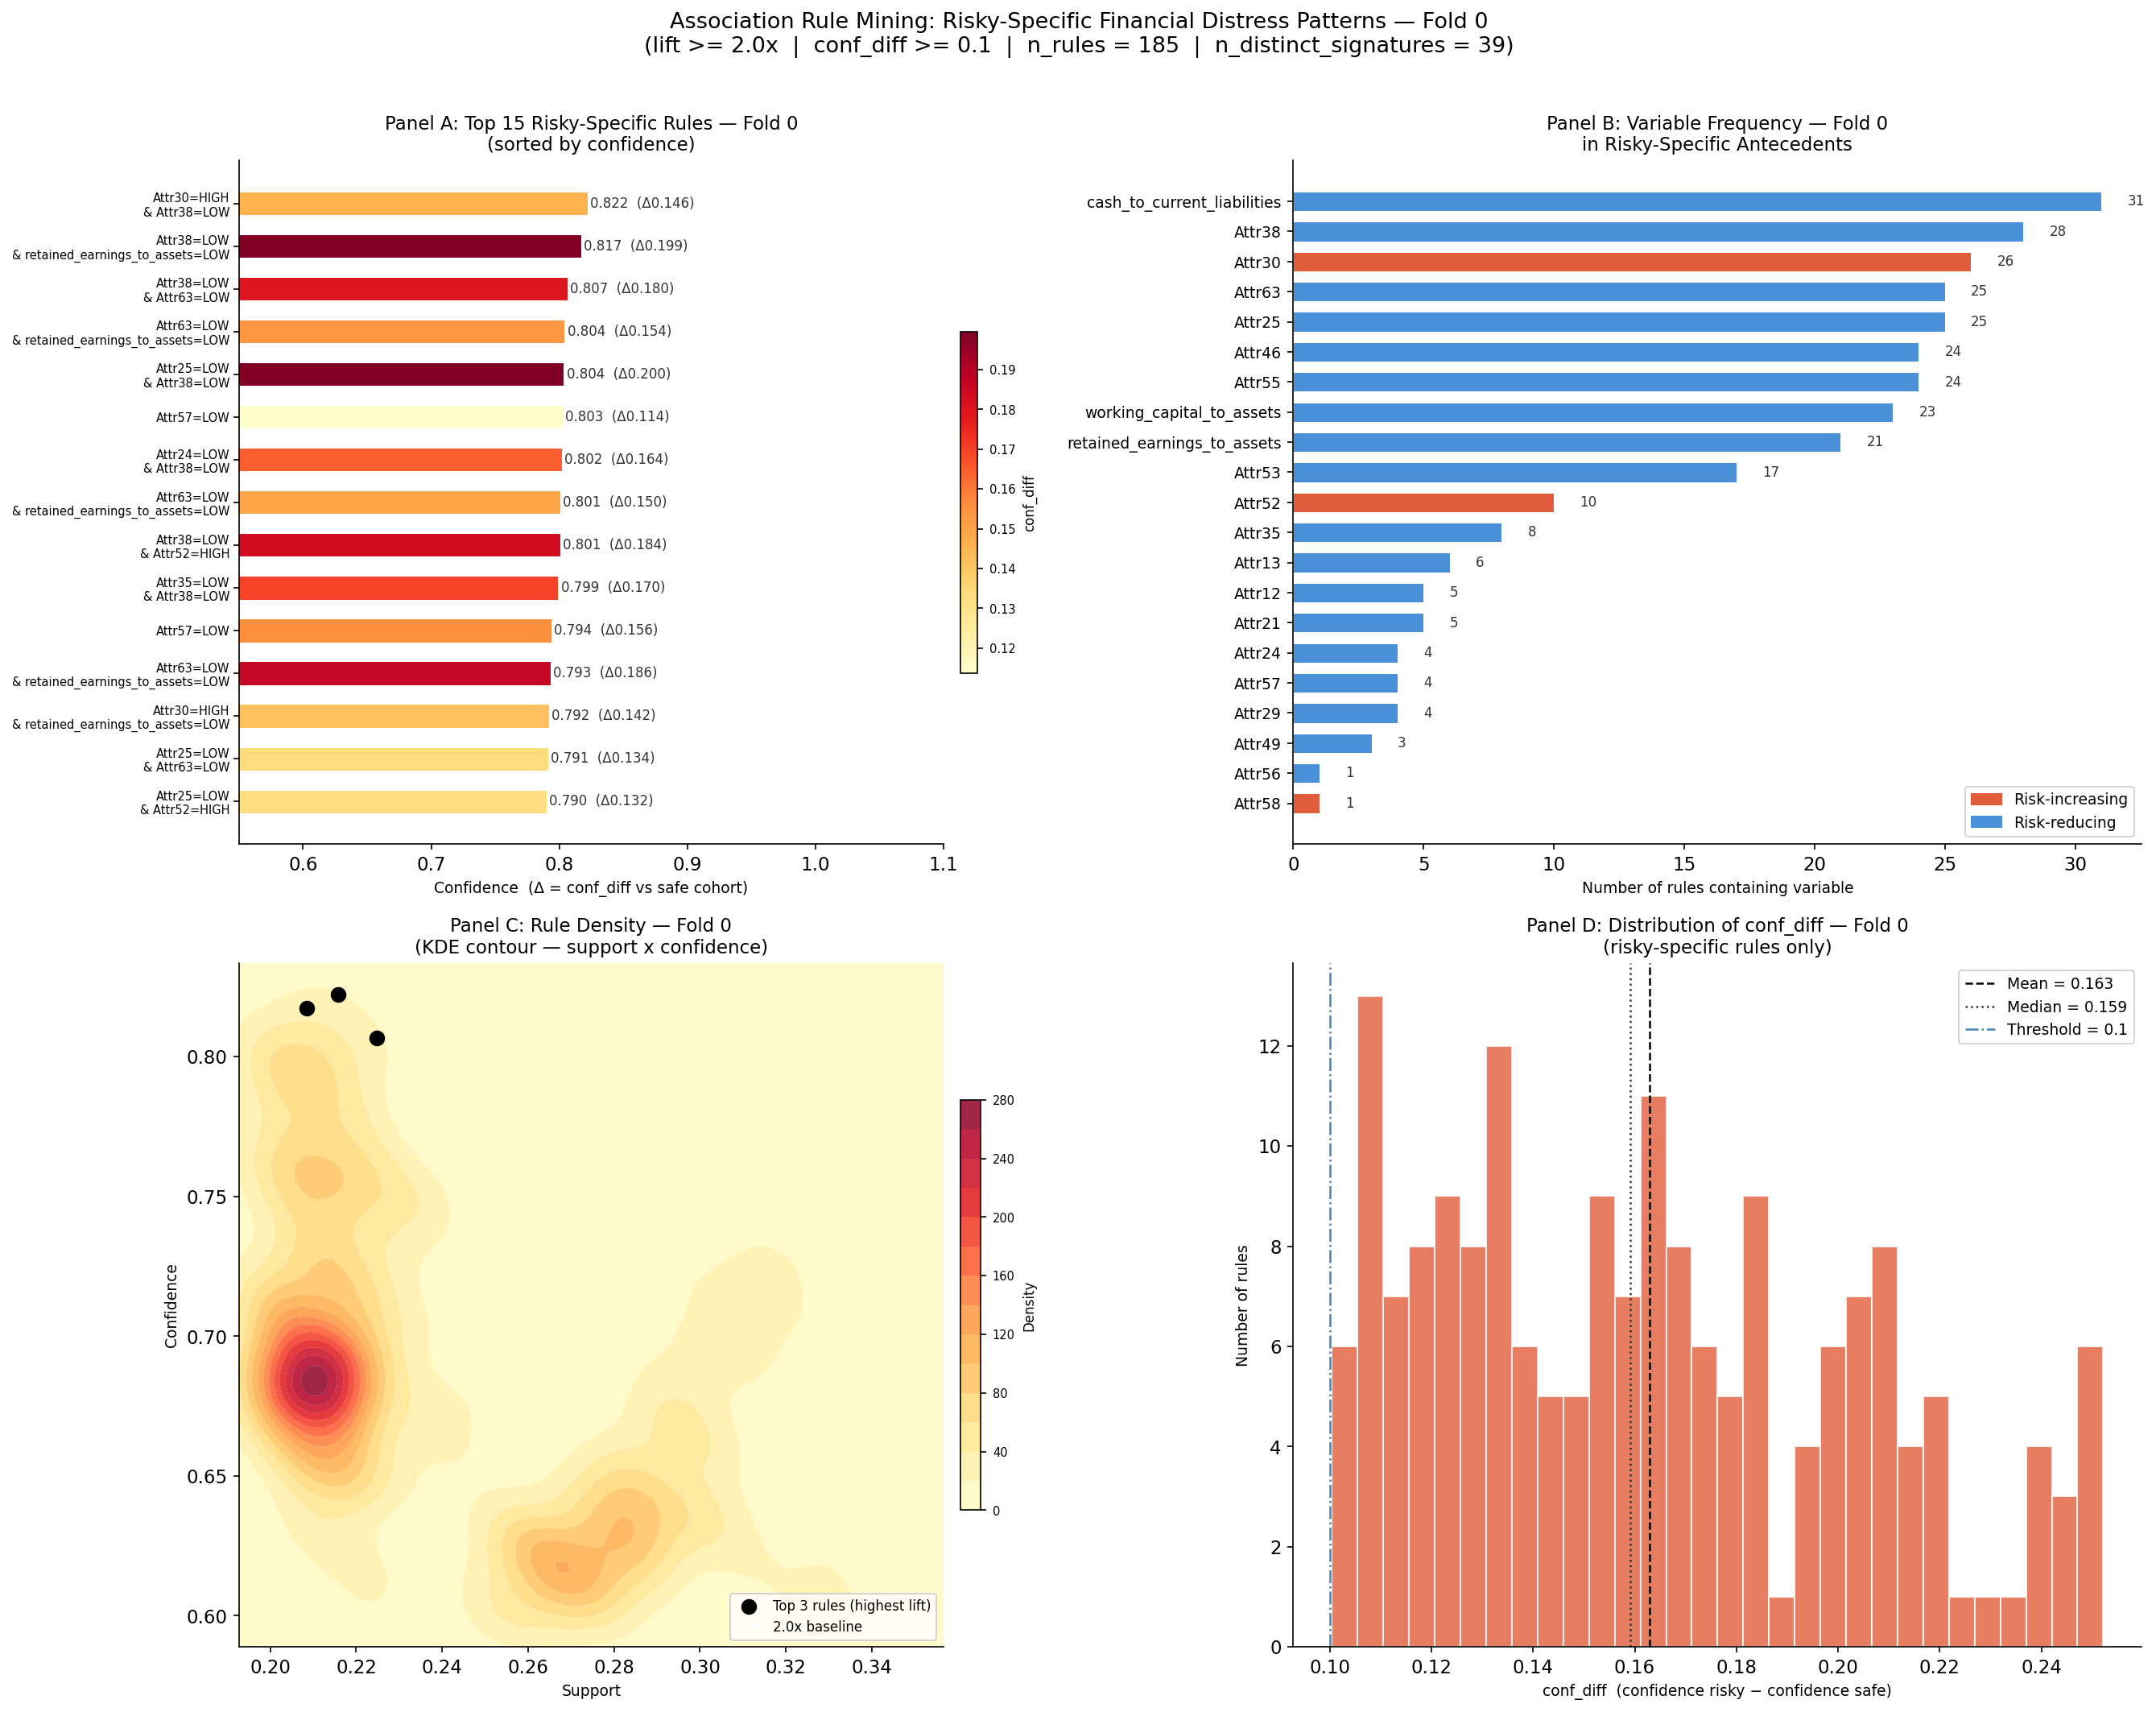

Figure saved: NB04_01_rule_analysis_fold0.png

NB04 SUMMARY — FOLD 0 (TRAIN PARTITION)
Variables used                            : 22
Correlation groups formed (agreement>=0.75) : 9
Baseline default rate                     : 8.73%
Total rules generated (risky)              : 8779
Risky-specific after original 4 filters    : 2766
Risky-specific after group filter added    : 185
Distinct group-combination signatures       : 39

Top 5 rules by lift vs baseline (fold 0):
  [Attr30=HIGH & Attr38=LOW]  ->  [Attr46=LOW]
    support=0.216  confidence=0.822  lift_vs_baseline=9.42x  conf_diff=0.146
  [Attr38=LOW & retained_earnings_to_assets=LOW]  ->  [Attr46=LOW]
    support=0.208  confidence=0.817  lift_vs_baseline=9.36x  conf_diff=0.199
  [Attr38=LOW & Attr63=LOW]  ->  [Attr46=LOW]
    support=0.225  confidence=0.807  lift_vs_baseline=9.24x  conf_diff=0.180
  [Attr63=LOW & retained_earnings_to_assets=LOW]  ->  [Attr12=LOW]
    support=0.203  confidence=0.804  lift_vs_baseline=9.22x  conf_dif

In [8]:
# ============================================================================
# NB04_association_rules.ipynb  —  Nested CV Version, fold 0 (FINAL)
#
# Study 2: Association rule mining on upgrade-overridden firms
#
# ----------------------------------------------------------------------------
# SUMMARY OF ALL REVISIONS FROM THE ORIGINAL SINGLE-SAMPLE NOTEBOOK
# ----------------------------------------------------------------------------
# 1. Input is fold 0's OUTER-TRAINING partition (N=12,537; risky_upgrade
#    n=1,094) with a 22-variable candidate set (vs. the paper's 16 —
#    see NB03/NB03b fold 0 output for why this fold retains more variables
#    after VIF screening at threshold=5, revised down from the paper's 10).
#
# 2. [Step 2b] A variable-grouping step was added. An initial run using
#    only the paper's original four filters (support/confidence/lift/
#    conf_diff) produced 2,766 risky-specific rules — ~5.6x the paper's
#    491 — dominated by rules that combine variables which are individually
#    below VIF/correlation duplicate thresholds, but are jointly proxies
#    for the same latent financial factor (verified via a raw-correlation
#    grouping attempt that failed to catch this, followed by a corrected
#    BINNED-LABEL AGREEMENT grouping — see Step 2b comments below for the
#    full diagnostic history).
#
# 3. [Step 5b] A fifth filter excludes rules where 2+ items ACROSS THE
#    ANTECEDENT AND CONSEQUENT belong to the same correlation group
#    (catching near-tautological rules like "Attr49=LOW -> Attr35=LOW"
#    where both are proxies for the same underlying factor).
#
# 4. [Philosophy shift] Matching the paper's exact rule count (491) was
#    deliberately abandoned as a goal. That number reflects what the
#    original 16-variable, single-sample pipeline happened to produce —
#    not a benchmark this fold's pipeline needs to hit. Instead, a
#    DIVERSITY diagnostic reports how many genuinely distinct
#    (antecedent-group-set, consequent-group) signatures exist among
#    surviving rules, directly measuring whether the library surfaces
#    varied hidden patterns or many restatements of a few patterns.
#
# 5. Panel A of the summary figure now uses a dynamic figure height and
#    reduced label/bar sizing to prevent y-axis label overlap when
#    antecedents have 3 conditions (an issue not present in the paper's
#    original 16-variable run, where rules were typically shorter).
#
# Input  : data/processed/fold_0/upgrade_cohort_fold0.parquet
#           -> filtered to outer_split == "train"
#          results/tables/NB03b_variable_map_fold0.csv  (22 variables)
# Outputs:
#   results/tables/NB04_01_rules_risky_fold0.csv
#   results/tables/NB04_02_rules_summary_fold0.csv
#   results/tables/NB04_03_top10_rules_fold0.csv
#   results/tables/NB04_04_variable_groups_fold0.csv
#   results/tables/NB04_05_signature_diversity_fold0.csv
#   results/figures/NB04_01_rule_analysis_fold0.png
# ============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
    "font.family"      : "DejaVu Sans",
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

RANDOM_SEED = 42
FOLD_ID     = 0   # will become a loop variable in the next version

# ── Parameters ────────────────────────────────────────────────────────────────

MIN_SUPPORT_RISKY    = 0.20
MIN_SUPPORT_SAFE     = 0.05
MIN_CONFIDENCE       = 0.60
LIFT_VS_BASELINE     = 2.0
MIN_CONF_DIFF        = 0.10
MAX_ANTECEDENT_LEN   = 3
AGREEMENT_THRESHOLD  = 0.75   # binned-label agreement rate for same-group clustering


# ── Load fold 0 train partition + NB03b's deduplicated variable list ────────

fold_cohort_path = os.path.join(PROC_DIR, f"fold_{FOLD_ID}", f"upgrade_cohort_fold{FOLD_ID}.parquet")
cohort_full_fold = pd.read_parquet(fold_cohort_path)
cohort = cohort_full_fold[cohort_full_fold["outer_split"] == "train"].copy()

var_map_path = os.path.join(TABLE_DIR, f"NB03b_variable_map_fold{FOLD_ID}.csv")
var_map    = pd.read_csv(var_map_path, index_col=0)
final_vars = var_map.index.tolist()

risky = cohort[cohort["group"] == "risky_upgrade"]
safe  = cohort[cohort["group"] == "safe_upgrade"]

BASELINE_DR = cohort["default"].mean()

print(f"Loaded fold {FOLD_ID} train partition : {cohort.shape}")
print(f"  risky_upgrade : {len(risky):,}  ({len(risky)/len(cohort)*100:.1f}%)")
print(f"  safe_upgrade  : {len(safe):,}  ({len(safe)/len(cohort)*100:.1f}%)")
print(f"  Baseline default rate : {BASELINE_DR*100:.2f}%")
print(f"Final variables for ARM (fold {FOLD_ID}) : {len(final_vars)}")
print(f"  [Note: original paper used 16 variables; this fold uses "
      f"{len(final_vars)} after VIF threshold=5 — see NB03/NB03b fold-specific output.]")
print(f"\nParameters:")
print(f"  min_support (risky)     : {MIN_SUPPORT_RISKY}")
print(f"  min_support (safe)      : {MIN_SUPPORT_SAFE}")
print(f"  min_confidence          : {MIN_CONFIDENCE}")
print(f"  lift_vs_baseline        : {LIFT_VS_BASELINE}x")
print(f"  min_conf_diff           : {MIN_CONF_DIFF}")
print(f"  max_antecedent_len      : {MAX_ANTECEDENT_LEN}")
print(f"  agreement_threshold     : {AGREEMENT_THRESHOLD}  [grouping]")


# ── Step 1: Discretisation ────────────────────────────────────────────────────

print(f"\n[Step 1] Discretising variables into bins (fold {FOLD_ID})...")

direction_map = var_map["direction"].to_dict()
binned        = pd.DataFrame(index=cohort.index)
bin_log       = []

for col in final_vars:
    direction = direction_map.get(col, "risk-reducing")
    vals      = cohort[col].dropna()
    p33       = vals.quantile(0.33)
    p67       = vals.quantile(0.67)

    def label_row(v, p33=p33, p67=p67):
        if pd.isna(v):
            return None
        if v <= p33:
            return f"{col}=LOW"
        elif v <= p67:
            return f"{col}=MID"
        else:
            return f"{col}=HIGH"

    binned[col]  = cohort[col].apply(label_row)
    distress_bin = "LOW" if direction == "risk-reducing" else "HIGH"
    bin_log.append({
        "feature"     : col,
        "direction"   : direction,
        "distress_bin": distress_bin,
        "p33"         : round(p33, 4),
        "p67"         : round(p67, 4),
    })
    print(f"  {col:<35s} distress={distress_bin}")

bin_log_df    = pd.DataFrame(bin_log).set_index("feature")
distress_items = {
    f"{col}={bin_log_df.loc[col, 'distress_bin']}"
    for col in final_vars
}


# ── Step 2: Build transactions ────────────────────────────────────────────────

print(f"\n[Step 2] Building transaction datasets (fold {FOLD_ID})...")

def make_transactions(idx_list, binned_df):
    transactions = []
    for idx in idx_list:
        if idx not in binned_df.index:
            continue
        items = [v for v in binned_df.loc[idx] if v is not None]
        if items:
            transactions.append(items)
    return transactions

risky_tx = make_transactions(risky.index, binned.loc[risky.index])
safe_tx  = make_transactions(safe.index,  binned.loc[safe.index])

print(f"  Transactions — risky_upgrade : {len(risky_tx):,}")
print(f"  Transactions — safe_upgrade  : {len(safe_tx):,}")


# ── Step 2b: Variable grouping via BINNED-LABEL agreement ────────────────────
#
# METHOD: for each variable, compute a binary "distress indicator" over the
# risky_upgrade cohort (1 if the firm's binned value equals that variable's
# defined distress direction — LOW for risk-reducing, HIGH for risk-
# increasing). Variables are grouped by AGREEMENT RATE between these
# indicators (fraction of risky-cohort firms where both flags agree),
# converted to a distance (1 - agreement) and clustered via average-linkage
# hierarchical clustering. This directly measures the quantity that drives
# Apriori's rule generation — how often two variables assign the SAME LOW/
# HIGH item to the same firms — rather than raw-value correlation, which an
# earlier diagnostic confirmed does not track this closely enough (e.g.
# Attr24-Attr49 binned agreement = 0.811 despite raw correlation being
# below a 0.60 threshold that failed to group them).

print(f"\n[Step 2b] Variable grouping via binned-label agreement (fold {FOLD_ID})")

distress_indicator = pd.DataFrame(index=risky.index)
for col in final_vars:
    direction    = direction_map.get(col, "risk-reducing")
    distress_bin = "LOW" if direction == "risk-reducing" else "HIGH"
    col_binned   = binned.loc[risky.index, col]
    distress_indicator[col] = (col_binned == f"{col}={distress_bin}").astype(int)

n_vars = len(final_vars)
agreement_matrix = np.zeros((n_vars, n_vars))

for i, v1 in enumerate(final_vars):
    for j, v2 in enumerate(final_vars):
        if i == j:
            agreement_matrix[i, j] = 1.0
        else:
            agree = (distress_indicator[v1] == distress_indicator[v2]).mean()
            agreement_matrix[i, j] = agree

distance_matrix = 1 - agreement_matrix
np.fill_diagonal(distance_matrix, 0)
distance_matrix = (distance_matrix + distance_matrix.T) / 2

condensed_dist = squareform(distance_matrix, checks=False)
Z = linkage(condensed_dist, method="average")

GROUP_DISTANCE_CUTOFF = 1 - AGREEMENT_THRESHOLD
cluster_labels = fcluster(Z, t=GROUP_DISTANCE_CUTOFF, criterion="distance")
var_to_group = dict(zip(final_vars, cluster_labels))

group_to_vars = {}
for var, grp in var_to_group.items():
    group_to_vars.setdefault(grp, []).append(var)

print(f"  Agreement threshold for grouping : >= {AGREEMENT_THRESHOLD}")
print(f"  Number of groups formed          : {len(group_to_vars)}")
print(f"\n  Groups with more than 1 member:")
n_multi_member_groups = 0
for grp, members in sorted(group_to_vars.items()):
    if len(members) > 1:
        n_multi_member_groups += 1
        print(f"    Group {grp}: {members}")

n_singleton_groups = sum(1 for m in group_to_vars.values() if len(m) == 1)
print(f"\n  Singleton groups : {n_singleton_groups}")
print(f"  Multi-member groups : {n_multi_member_groups}")

group_records = [
    {"feature": var, "group_id": grp, "group_members": " & ".join(group_to_vars[grp])}
    for var, grp in var_to_group.items()
]
group_df = pd.DataFrame(group_records).set_index("feature")
group_out_path = os.path.join(TABLE_DIR, f"NB04_04_variable_groups_fold{FOLD_ID}.csv")
group_df.to_csv(group_out_path)
print(f"\n  Saved: {group_out_path}")


# ── One-hot encode ────────────────────────────────────────────────────────────

te       = TransactionEncoder()
risky_oh = pd.DataFrame(te.fit_transform(risky_tx), columns=te.columns_)

te_safe  = TransactionEncoder()
safe_oh  = pd.DataFrame(te_safe.fit_transform(safe_tx), columns=te_safe.columns_)


# ── Step 3: Apriori — risky cohort ────────────────────────────────────────────

print(f"\n[Step 3] Apriori — risky_upgrade cohort (fold {FOLD_ID})...")

freq_risky  = apriori(risky_oh, min_support=MIN_SUPPORT_RISKY,
                      use_colnames=True, max_len=MAX_ANTECEDENT_LEN + 1)
rules_risky = association_rules(freq_risky, metric="confidence",
                                min_threshold=MIN_CONFIDENCE)
rules_risky = rules_risky[
    rules_risky["antecedents"].apply(len) <= MAX_ANTECEDENT_LEN
]
rules_risky["lift_vs_baseline"]  = rules_risky["confidence"] / BASELINE_DR
rules_risky["antecedents_str"]   = rules_risky["antecedents"].apply(
    lambda x: " & ".join(sorted(x)))
rules_risky["consequents_str"]   = rules_risky["consequents"].apply(
    lambda x: " & ".join(sorted(x)))
rules_risky["has_distress"]      = rules_risky["antecedents"].apply(
    lambda x: bool(set(x) & distress_items))

print(f"  Frequent itemsets : {len(freq_risky)}")
print(f"  Association rules : {len(rules_risky)}")


# ── Step 4: Apriori — safe cohort ─────────────────────────────────────────────

print(f"\n[Step 4] Apriori — safe_upgrade cohort (fold {FOLD_ID})...")

freq_safe = apriori(safe_oh, min_support=MIN_SUPPORT_SAFE,
                    use_colnames=True, max_len=MAX_ANTECEDENT_LEN + 1)

if len(freq_safe) > 0:
    rules_safe = association_rules(freq_safe, metric="confidence",
                                   min_threshold=0.10)
    rules_safe = rules_safe[
        rules_safe["antecedents"].apply(len) <= MAX_ANTECEDENT_LEN
    ]
    rules_safe["antecedents_str"] = rules_safe["antecedents"].apply(
        lambda x: " & ".join(sorted(x)))
    rules_safe["consequents_str"] = rules_safe["consequents"].apply(
        lambda x: " & ".join(sorted(x)))
    safe_conf_lookup = {
        (row["antecedents_str"], row["consequents_str"]): row["confidence"]
        for _, row in rules_safe.iterrows()
    }
    safe_ant_set = {k[0] for k in safe_conf_lookup.keys()}
    print(f"  Frequent itemsets : {len(freq_safe)}")
    print(f"  Association rules : {len(rules_safe)}")
else:
    safe_conf_lookup = {}
    safe_ant_set     = set()
    print("  No frequent itemsets found in safe cohort.")


# ── Step 5: Risky-specific rule filtering ─────────────────────────────────────

print(f"\n[Step 5] Filtering risky-specific rules (fold {FOLD_ID})...")

conf_safe_list = []
for _, row in rules_risky.iterrows():
    key = (row["antecedents_str"], row["consequents_str"])
    conf_safe_list.append(safe_conf_lookup.get(key, np.nan))

rules_risky["conf_safe"]       = conf_safe_list
rules_risky["conf_diff"]       = (rules_risky["confidence"] -
                                   rules_risky["conf_safe"].fillna(0))
rules_risky["safe_ant_present"] = rules_risky["antecedents_str"].isin(safe_ant_set)


# ── Step 5b: Same-group redundancy filter (antecedent + consequent) ──────────
#
# A rule is excluded if 2+ items ACROSS THE WHOLE RULE (antecedent AND
# consequent together) belong to the same correlation group — catching
# near-tautological rules like "Attr49=LOW -> Attr35=LOW" where both
# variables are proxies for the same latent factor (Group 6 in this fold:
# Attr49, Attr13, Attr24, Attr35, Attr41, Attr56, Attr12, Attr58).

def rule_has_group_redundancy(antecedent_frozenset, consequent_frozenset, var_to_group):
    all_items = list(antecedent_frozenset) + list(consequent_frozenset)
    groups_seen = []
    for item in all_items:
        var = item.split("=")[0]
        grp = var_to_group.get(var)
        if grp is not None:
            groups_seen.append(grp)
    return len(groups_seen) != len(set(groups_seen))

rules_risky["group_redundant"] = rules_risky.apply(
    lambda row: rule_has_group_redundancy(
        row["antecedents"], row["consequents"], var_to_group
    ),
    axis=1
)

n_redundant = rules_risky["group_redundant"].sum()
print(f"\n  [Step 5b] Same-group redundancy check (antecedent + consequent):")
print(f"    Rules with 2+ items (across antecedent+consequent) from the same "
      f"correlation group: {n_redundant} / {len(rules_risky)}")

n_after_original_four = (
    rules_risky["safe_ant_present"]
    & (rules_risky["conf_diff"] >= MIN_CONF_DIFF)
    & (rules_risky["lift_vs_baseline"] >= LIFT_VS_BASELINE)
    & rules_risky["has_distress"]
).sum()

risky_specific = rules_risky[
    (rules_risky["safe_ant_present"]    == True)  &
    (rules_risky["conf_diff"]           >= MIN_CONF_DIFF) &
    (rules_risky["lift_vs_baseline"]    >= LIFT_VS_BASELINE) &
    (rules_risky["has_distress"]        == True) &
    (rules_risky["group_redundant"]     == False)
].sort_values(
    ["lift_vs_baseline", "confidence", "support"], ascending=False
).reset_index(drop=True)

print(f"\n  Total rules (risky cohort)                          : {len(rules_risky)}")
print(f"  Rules with safe antecedent present                   : {rules_risky['safe_ant_present'].sum()}")
print(f"  Risky-specific after ORIGINAL four filters           : {n_after_original_four}")
print(f"  Risky-specific after group filter (ant+cons) added   : {len(risky_specific)}")
print(f"  [Note: matching the paper's 491 is no longer the target — see "
      f"philosophy note in the module docstring. This reflects fold 0's "
      f"own 22-variable candidate set after removing near-tautological rules.]")

# Save
out_path = os.path.join(TABLE_DIR, f"NB04_01_rules_risky_fold{FOLD_ID}.csv")
rules_risky.to_csv(out_path, index=False)
print(f"\n  Saved all risky rules  : {out_path}")

out_path = os.path.join(TABLE_DIR, f"NB04_02_rules_summary_fold{FOLD_ID}.csv")
risky_specific[["antecedents_str", "consequents_str", "support",
                "confidence", "lift", "lift_vs_baseline",
                "conf_safe", "conf_diff"]].to_csv(out_path, index=False)
print(f"  Saved risky-specific   : {out_path}")

if len(risky_specific) > 0:
    print(f"\nTop 20 risky-specific rules (fold {FOLD_ID}):")
    print(
        risky_specific[["antecedents_str", "consequents_str", "support",
                         "confidence", "lift_vs_baseline",
                         "conf_safe", "conf_diff"]]
        .head(20).to_string(index=False)
    )
else:
    print(
        "  [WARNING] No risky-specific rules survived all filters in this "
        "fold. Consider whether AGREEMENT_THRESHOLD is too strict."
    )


# ── [NEW] Group-combination diversity diagnostic ──────────────────────────────
#
# For each surviving rule, compute its "signature": the SET of correlation
# groups in the antecedent, paired with the group of the consequent. Rules
# sharing a signature encode the same underlying latent-factor combination,
# even with different specific variables/thresholds. Counting DISTINCT
# signatures answers: how many genuinely different hidden patterns survive,
# independent of how many individual rule instances restate each one.

def rule_group_signature(antecedent_frozenset, consequent_frozenset, var_to_group):
    ant_groups = frozenset(
        var_to_group.get(item.split("=")[0]) for item in antecedent_frozenset
    )
    cons_groups = frozenset(
        var_to_group.get(item.split("=")[0]) for item in consequent_frozenset
    )
    return (ant_groups, cons_groups)

if len(risky_specific) > 0:
    risky_specific["group_signature"] = risky_specific.apply(
        lambda row: rule_group_signature(
            row["antecedents"], row["consequents"], var_to_group
        ),
        axis=1
    )

    n_distinct_signatures = risky_specific["group_signature"].nunique()
    signature_counts = risky_specific["group_signature"].value_counts()

    print(f"\n  [Diversity diagnostic]")
    print(f"    Surviving rules                              : {len(risky_specific)}")
    print(f"    Distinct (antecedent-groups, consequent-group) signatures : "
          f"{n_distinct_signatures}")
    print(f"    Average rules per distinct signature          : "
          f"{len(risky_specific) / n_distinct_signatures:.1f}")
    print(f"\n    Top 10 most-repeated signatures (by rule count):")
    for i, (sig, count) in enumerate(signature_counts.head(10).items(), 1):
        ant_grp_ids, cons_grp_id = sig
        print(f"      {i}. antecedent groups {list(ant_grp_ids)} -> "
              f"consequent group {list(cons_grp_id)}  ({count} rule instances)")

    signature_summary = (
        risky_specific.groupby(risky_specific["group_signature"].astype(str))
        .agg(
            n_rule_instances=("support", "size"),
            max_lift=("lift_vs_baseline", "max"),
            max_confidence=("confidence", "max"),
        )
        .sort_values("n_rule_instances", ascending=False)
    )
    sig_out_path = os.path.join(TABLE_DIR, f"NB04_05_signature_diversity_fold{FOLD_ID}.csv")
    signature_summary.to_csv(sig_out_path)
    print(f"\n    Saved signature-level diversity summary: {sig_out_path}")
else:
    n_distinct_signatures = 0
    print("\n  [Diversity diagnostic] No surviving rules to analyze.")


# ── Top 10 rules — console print + CSV ────────────────────────────────────────

print("\n" + "=" * 65)
print(f"TOP 10 RISKY-SPECIFIC RULES (fold {FOLD_ID}, for paper table)")
print("=" * 65)

if len(risky_specific) > 0:
    top10 = risky_specific.head(10).copy()
    top10.index = np.arange(1, len(top10) + 1)
    top10.index.name = "Rank"

    print(
        top10[["antecedents_str", "consequents_str", "support",
               "confidence", "lift_vs_baseline", "conf_safe", "conf_diff"]]
        .rename(columns={
            "antecedents_str" : "Antecedent",
            "consequents_str" : "Consequent",
            "support"         : "Support",
            "confidence"      : "Confidence",
            "lift_vs_baseline": "Lift×Base",
            "conf_safe"       : "Conf(safe)",
            "conf_diff"       : "Conf Diff",
        })
        .round(3)
        .to_string()
    )

    out_path = os.path.join(TABLE_DIR, f"NB04_03_top10_rules_fold{FOLD_ID}.csv")
    top10.to_csv(out_path)
    print(f"\nSaved: {out_path}  (use this CSV directly for paper table)")
else:
    print("  No rules to display.")


# ── Figure 1: 2×2 rule analysis ───────────────────────────────────────────────

print(f"\n[Figure 1] 2x2 association rule analysis (fold {FOLD_ID})")

if len(risky_specific) > 0:

    top15_preview = risky_specific.head(15).copy()
    max_lines_in_label = top15_preview["antecedents_str"].apply(
        lambda s: len(s.split(" & "))
    ).max()
    dynamic_height = max(14, 8 + max_lines_in_label * 1.2)

    fig, axes = plt.subplots(2, 2, figsize=(18, dynamic_height))
    ax_bar  = axes[0, 0]
    ax_freq = axes[0, 1]
    ax_kde  = axes[1, 0]
    ax_hist = axes[1, 1]


    # Panel A: Top 15 rules — horizontal bar chart
    top15 = risky_specific.head(15).copy()
    top15 = top15.sort_values("confidence", ascending=True).reset_index(drop=True)
    top15["short_label"] = top15["antecedents_str"].apply(
        lambda s: "\n& ".join(s.split(" & "))
    )
    norm_diff  = plt.Normalize(top15["conf_diff"].min(), top15["conf_diff"].max())
    bar_colors = plt.cm.YlOrRd(norm_diff(top15["conf_diff"].values))

    ax_bar.barh(np.arange(len(top15)), top15["confidence"],
                color=bar_colors, edgecolor="white", linewidth=0.5, height=0.55)
    for i, (conf, diff) in enumerate(zip(top15["confidence"], top15["conf_diff"])):
        ax_bar.text(conf + 0.002, i, f"{conf:.3f}  (Δ{diff:.3f})",
                    va="center", fontsize=8, color="#333333")

    ax_bar.set_yticks(np.arange(len(top15)))
    ax_bar.set_yticklabels(top15["short_label"], fontsize=7)
    ax_bar.tick_params(axis='y', pad=2)
    ax_bar.set_xlim(0.55, 1.10)
    ax_bar.set_xlabel("Confidence  (Δ = conf_diff vs safe cohort)", fontsize=9)
    ax_bar.set_title(f"Panel A: Top 15 Risky-Specific Rules — Fold {FOLD_ID}\n(sorted by confidence)",
                     fontsize=11)
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm_diff)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax_bar, shrink=0.5, pad=0.02)
    cb.set_label("conf_diff", fontsize=8)
    cb.ax.tick_params(labelsize=7)


    # Panel B: Variable frequency in antecedents
    var_counts = {}
    for _, row in risky_specific.iterrows():
        for item in row["antecedents"]:
            var = item.split("=")[0]
            var_counts[var] = var_counts.get(var, 0) + 1

    freq_df = (
        pd.Series(var_counts).sort_values(ascending=True)
        .reset_index()
    )
    freq_df.columns = ["variable", "count"]
    freq_colors = [
        "#E05C3A" if var_map.loc[v, "direction"] == "risk-increasing"
        else "#4A90D9"
        for v in freq_df["variable"] if v in var_map.index
    ]
    while len(freq_colors) < len(freq_df):
        freq_colors.insert(0, "#AAAAAA")

    ax_freq.barh(np.arange(len(freq_df)), freq_df["count"],
                 color=freq_colors, edgecolor="white", linewidth=0.5, height=0.65)
    for i, cnt in enumerate(freq_df["count"]):
        ax_freq.text(cnt + 1, i, str(cnt), va="center", fontsize=8,
                     color="#333333")

    ax_freq.set_yticks(np.arange(len(freq_df)))
    ax_freq.set_yticklabels(freq_df["variable"], fontsize=9)
    ax_freq.set_xlabel("Number of rules containing variable", fontsize=9)
    ax_freq.set_title(f"Panel B: Variable Frequency — Fold {FOLD_ID}\nin Risky-Specific Antecedents",
                      fontsize=11)
    red_p  = mpatches.Patch(color="#E05C3A", label="Risk-increasing")
    blue_p = mpatches.Patch(color="#4A90D9", label="Risk-reducing")
    ax_freq.legend(handles=[red_p, blue_p], fontsize=9, loc="lower right")


    # Panel C: KDE contour
    x = risky_specific["support"].values
    y = risky_specific["confidence"].values

    if len(risky_specific) >= 3:
        x_pad = (x.max() - x.min()) * 0.05 if x.max() > x.min() else 0.01
        y_pad = (y.max() - y.min()) * 0.05 if y.max() > y.min() else 0.01
        x_min, x_max = x.min() - x_pad, x.max() + x_pad
        y_min, y_max = y.min() - y_pad, y.max() + y_pad

        xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
        kde    = gaussian_kde(np.vstack([x, y]), bw_method=0.20)
        z      = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

        cf = ax_kde.contourf(xx, yy, z, levels=14, cmap="YlOrRd", alpha=0.85)
        ax_kde.contour(xx, yy, z, levels=14, colors="white",
                       linewidths=0.3, alpha=0.4)

        ax_kde.set_xlim(x_min, x_max)
        ax_kde.set_ylim(y_min, y_max)

        cb2 = plt.colorbar(cf, ax=ax_kde, shrink=0.6, pad=0.02)
        cb2.set_label("Density", fontsize=8)
        cb2.ax.tick_params(labelsize=7)

        top3 = risky_specific.head(3)
        ax_kde.scatter(top3["support"], top3["confidence"],
                       c="black", s=70, zorder=5, label="Top 3 rules (highest lift)")
        ax_kde.axhline(BASELINE_DR * LIFT_VS_BASELINE, color="white",
                       linestyle="--", linewidth=1.2,
                       label=f"{LIFT_VS_BASELINE}x baseline")
        ax_kde.set_xlabel("Support", fontsize=9)
        ax_kde.set_ylabel("Confidence", fontsize=9)
        ax_kde.set_title(f"Panel C: Rule Density — Fold {FOLD_ID}\n(KDE contour — support x confidence)",
                         fontsize=11)
        ax_kde.legend(fontsize=8, loc="lower right")
    else:
        ax_kde.text(0.5, 0.5, "Too few rules for KDE\n(need >= 3)",
                    ha="center", va="center", transform=ax_kde.transAxes)
        ax_kde.set_title(f"Panel C: Rule Density — Fold {FOLD_ID}", fontsize=11)


    # Panel D: conf_diff distribution
    ax_hist.hist(risky_specific["conf_diff"], bins=min(30, max(5, len(risky_specific)//2)),
                 color="#E05C3A", alpha=0.80, edgecolor="white")
    ax_hist.axvline(risky_specific["conf_diff"].mean(), color="black",
                    linestyle="--", linewidth=1.2,
                    label=f"Mean = {risky_specific['conf_diff'].mean():.3f}")
    ax_hist.axvline(risky_specific["conf_diff"].median(), color="#333333",
                    linestyle=":", linewidth=1.2,
                    label=f"Median = {risky_specific['conf_diff'].median():.3f}")
    ax_hist.axvline(MIN_CONF_DIFF, color="steelblue",
                    linestyle="-.", linewidth=1.2,
                    label=f"Threshold = {MIN_CONF_DIFF}")
    ax_hist.set_xlabel("conf_diff  (confidence risky − confidence safe)", fontsize=9)
    ax_hist.set_ylabel("Number of rules", fontsize=9)
    ax_hist.set_title(f"Panel D: Distribution of conf_diff — Fold {FOLD_ID}\n(risky-specific rules only)",
                      fontsize=11)
    ax_hist.legend(fontsize=9)

    plt.suptitle(
        f"Association Rule Mining: Risky-Specific Financial Distress Patterns — Fold {FOLD_ID}\n"
        f"(lift >= {LIFT_VS_BASELINE}x  |  conf_diff >= {MIN_CONF_DIFF}"
        f"  |  n_rules = {len(risky_specific)}  |  n_distinct_signatures = {n_distinct_signatures})",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"NB04_01_rule_analysis_fold{FOLD_ID}.png", bbox_inches="tight")
    plt.show()
    print(f"Figure saved: NB04_01_rule_analysis_fold{FOLD_ID}.png")
else:
    print("  Skipping figure — no risky-specific rules to plot.")


# ── Summary ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print(f"NB04 SUMMARY — FOLD {FOLD_ID} (TRAIN PARTITION)")
print("=" * 65)
print(f"Variables used                            : {len(final_vars)}")
print(f"Correlation groups formed (agreement>={AGREEMENT_THRESHOLD}) : {len(group_to_vars)}")
print(f"Baseline default rate                     : {BASELINE_DR*100:.2f}%")
print(f"Total rules generated (risky)              : {len(rules_risky)}")
print(f"Risky-specific after original 4 filters    : {n_after_original_four}")
print(f"Risky-specific after group filter added    : {len(risky_specific)}")
print(f"Distinct group-combination signatures       : {n_distinct_signatures}")

if len(risky_specific) > 0:
    print(f"\nTop 5 rules by lift vs baseline (fold {FOLD_ID}):")
    for _, row in risky_specific.head(5).iterrows():
        print(f"  [{row['antecedents_str']}]  ->  [{row['consequents_str']}]")
        print(f"    support={row['support']:.3f}  confidence={row['confidence']:.3f}"
              f"  lift_vs_baseline={row['lift_vs_baseline']:.2f}x"
              f"  conf_diff={row['conf_diff']:.3f}")

print(f"\nNext step -> NB05_clustering.ipynb (adapted for per-fold input)")